In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb

In [3]:
# load dataset
data = load_breast_cancer()

# convert to dataframe
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# explore
print("Shape:", df.shape)
print("\nClass distribution:")
print(df['target'].value_counts())
print("\nFirst 5 rows:")
df.head()

Shape: (569, 31)

Class distribution:
target
1    357
0    212
Name: count, dtype: int64

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


/var/folders/3j/n4qp82t925xd9vt8y2gnryy40000gn/T/ipykernel_75761/799521000.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


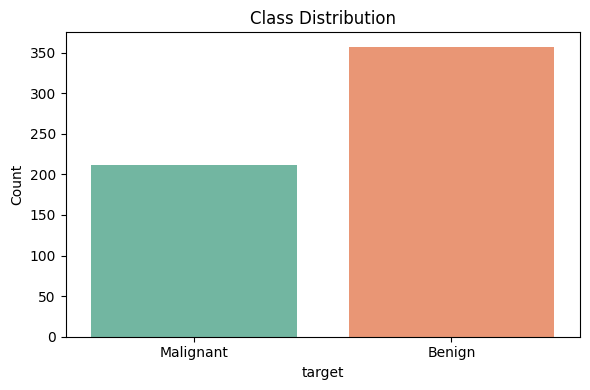

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df, palette='Set2')
plt.xticks([0,1], ['Malignant', 'Benign'])
plt.title('Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [5]:
# separate features and target
X = df.drop('target', axis=1)
y = df['target']

# stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

# train random forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# evaluate
y_pred = rf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

Training samples: 455
Test samples: 114

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



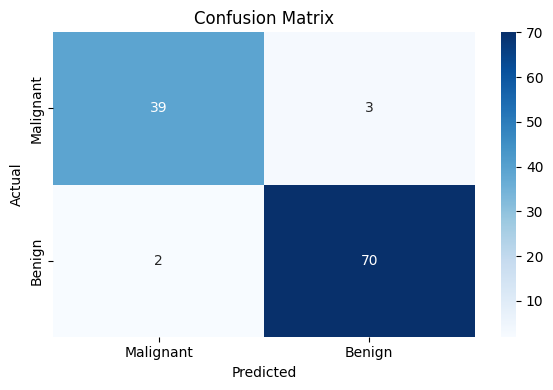

In [6]:
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant','Benign'],
            yticklabels=['Malignant','Benign'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [7]:
# stratified 5-fold cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='f1')

print("F1 scores per fold:", cv_scores.round(3))
print("Mean F1:", cv_scores.mean().round(3))
print("Std:", cv_scores.std().round(3))

F1 scores per fold: [0.971 0.952 0.966 0.957 0.979]
Mean F1: 0.965
Std: 0.01


In [8]:
from xgboost import XGBClassifier

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=10000, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

print("Model Comparison (Stratified 5-Fold CV)\n")
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='f1')
    print(f"{name}: Mean F1 = {scores.mean():.3f} | Std = {scores.std():.3f}")

Model Comparison (Stratified 5-Fold CV)

Random Forest: Mean F1 = 0.965 | Std = 0.010
Logistic Regression: Mean F1 = 0.964 | Std = 0.014
XGBoost: Mean F1 = 0.971 | Std = 0.008


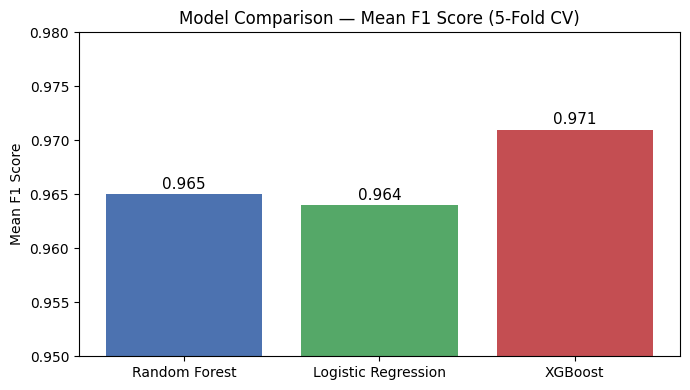

In [9]:
results = {
    'Random Forest': 0.965,
    'Logistic Regression': 0.964,
    'XGBoost': 0.971
}

plt.figure(figsize=(7,4))
bars = plt.bar(results.keys(), results.values(), color=['#4C72B0','#55A868','#C44E52'])
plt.ylim(0.95, 0.98)
plt.title('Model Comparison — Mean F1 Score (5-Fold CV)')
plt.ylabel('Mean F1 Score')
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
             f'{val:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()